## Imports

In [49]:
import sys
sys.path.append("/scratch/pl2820/ecog_slds")

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

%matplotlib inline

import seaborn as sns

sns.set_style("white")
sns.set_context("talk")

color_names = ["windows blue",
               "red",
               "amber",
               "faded green",
               "dusty purple",
               "orange",
               "clay",
               "pink",
               "greyish",
               "mint",
               "cyan",
               "steel blue",
               "forest green",
               "pastel purple",
               "salmon",
               "dark brown"]

colors = sns.xkcd_palette(color_names)
cmap = ListedColormap(colors)

save_figures = False
import jax.numpy as jnp
import jax.random as jr
from jax import vmap
import numpy as np
from sklearn.decomposition import PCA
from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from dynamax.hidden_markov_model import HMM
from data import EcogTaskPreProcessing

## Load ECoG data

In [1]:
subj = "NY742"
tasks = ["AudRep", "PicN", "VisRead"]
subj_dir = f"/scratch/pl2820/ecog_slds/Data/{subj}"

epoch_start = -256  # -0.5 sec before stim onset # ds 230 Hz
epoch_end = 1024  # 2 sec after stim onset
flag_response_lock = False
normalization_mode = "MultiBandHG"
flag_clean_time_before_zscore = True
number_log_dist_bands = 4

ecogdata = {}
for task in tasks:
    EP = EcogTaskPreProcessing(subj, task,
                               subj_dir = subj_dir, 
                               epoch_start = epoch_start,
                               epoch_end = epoch_end,
                               flag_response_lock = flag_response_lock,
                               normalization_mode = normalization_mode,
                               flag_clean_time_before_zscore = flag_clean_time_before_zscore,
                               number_log_dist_bands = number_log_dist_bands)
    trial_data, coords = EP.get_ecogdata()
    print(f"loaded data for task: {task}, {trial_data.shape}")
    ecogdata[task] = trial_data[:128,...]

loading data for subject: NY742 tasks: AudRep
loading /scratch/pl2820/ecog_slds/Data/NY742/data/AudRep/gdat_CAR.mat
preprocessing ...
loading events and running auto epoch ...
loading csv...
loaded data for task: AudRep, (172, 100, 1280)
loading data for subject: NY742 tasks: PicN
loading /scratch/pl2820/ecog_slds/Data/NY742/data/PicN/gdat_CAR.mat
preprocessing ...
loading events and running auto epoch ...
loading csv...
loaded data for task: PicN, (172, 100, 1280)
loading data for subject: NY742 tasks: VisRead
loading /scratch/pl2820/ecog_slds/Data/NY742/data/VisRead/gdat_CAR.mat
preprocessing ...
loading events and running auto epoch ...
loading csv...
loaded data for task: VisRead, (172, 100, 1280)


## Average over all task

In [8]:
# Trial-average each task and concatenate for shared PCA
for task in tasks:
    print(f"{task}: {ecogdata[task].shape}")

AudRep: (128, 100, 1280)
PicN: (128, 100, 1280)
VisRead: (128, 100, 1280)


## Manually construct ARHMM (transition matrices)

### Very sticky transition (**10)

In [5]:
num_states = 5

# Sticky with forward bias
transition_probs = (jnp.arange(num_states)**10).astype(float)
transition_probs /= transition_probs.sum()
transition_matrix = jnp.zeros((num_states, num_states))
for k, p in enumerate(transition_probs[::-1]):
    transition_matrix += jnp.roll(p * jnp.eye(num_states), k, axis = 1)

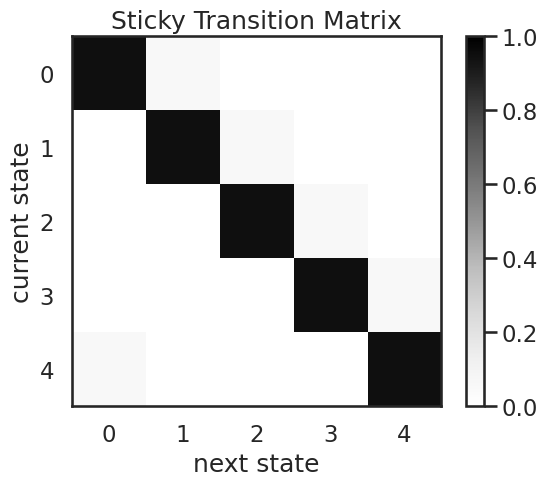

In [7]:
plt.imshow(transition_matrix, vmin = 0, vmax = 1, cmap = "Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("Sticky Transition Matrix")
plt.colorbar()
plt.show()

## Fit the ARHMM (AudRep, PicN, VisRead)

### Stack trials for each task -> the model will learn/train from 100 trials for each task

In [27]:
batch_emissions = {}
for task in tasks:
    batch_emissions[task] = jnp.stack(
        [ecogdata[task][:, i, :].T for i in range(100)]
    )
    print(f"{task}: {batch_emissions[task].shape}")

AudRep: (100, 1280, 128)
PicN: (100, 1280, 128)
VisRead: (100, 1280, 128)


### Create model and compute lagged Inputs:

In [28]:
num_lags = 1
emission_dim = 128  # number of electrodes

arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags = num_lags)

batch_inputs = {}
for task in tasks:
    batch_inputs[task] = vmap(arhmm.compute_inputs)(batch_emissions[task])
    print(f"{task} inputs: {batch_inputs[task].shape}")

AudRep inputs: (100, 1280, 128)
PicN inputs: (100, 1280, 128)
VisRead inputs: (100, 1280, 128)


### Initialize with kmeans and fit with EM

In [57]:
fitted = {}
for task in tasks:
    print(f"\n === Task: {task} ===")
    params, props = arhmm.initialize(
        key = jr.PRNGKey(1),
        method = 'kmeans',
        emissions = batch_emissions[task],
        transition_matrix = transition_matrix,
    )

    fitted_params, lps = arhmm.fit_em(
        params, props,
        batch_emissions[task],
        inputs = batch_inputs[task],
        num_iters = 200,
    )

    fitted[task] = {'params': fitted_params, 'lps': lps}
    print(f" Final log-prob: {lps[-1]:.2f}")


 === Task: AudRep ===


<div><progress max="200" value="200"></progress> 100.00% [200/200 02:46&lt;00:00]</div>

 Final log-prob: 24803538.00

 === Task: PicN ===


<div><progress max="200" value="200"></progress> 100.00% [200/200 02:47&lt;00:00]</div>

 Final log-prob: 24558334.00

 === Task: VisRead ===


<div><progress max="200" value="200"></progress> 100.00% [200/200 02:46&lt;00:00]</div>

 Final log-prob: 24647140.00


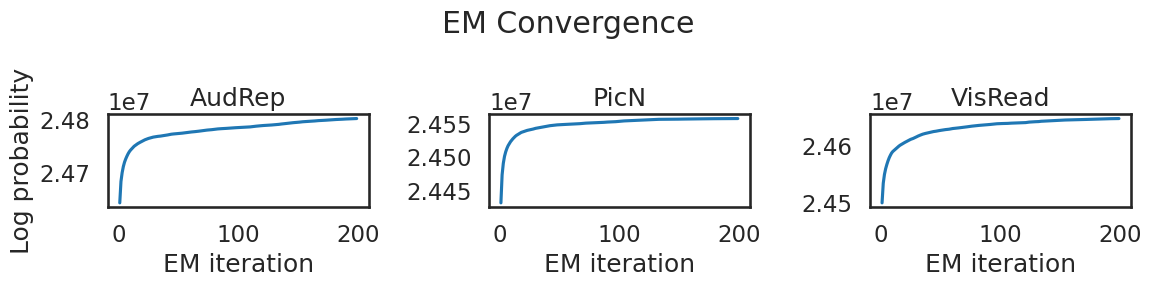

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, task in zip(axes, tasks):
    ax.plot(fitted[task]['lps'])
    ax.set_xlabel("EM iteration")
    ax.set_title(task)
    if ax == axes[0]:
        ax.set_ylabel("Log probability")
plt.suptitle("EM Convergence")
plt.tight_layout()
plt.show()

### Viterbi decoding

In [59]:
state_seqs = {}
for task in tasks:
    state_seqs[task] = vmap(
        lambda e, i: arhmm.most_likely_states(fitted[task]['params'], e, inputs = i)
    )(batch_emissions[task], batch_inputs[task])
    print(f"{task} states: {state_seqs[task].shape}")

AudRep states: (100, 1280)
PicN states: (100, 1280)
VisRead states: (100, 1280)


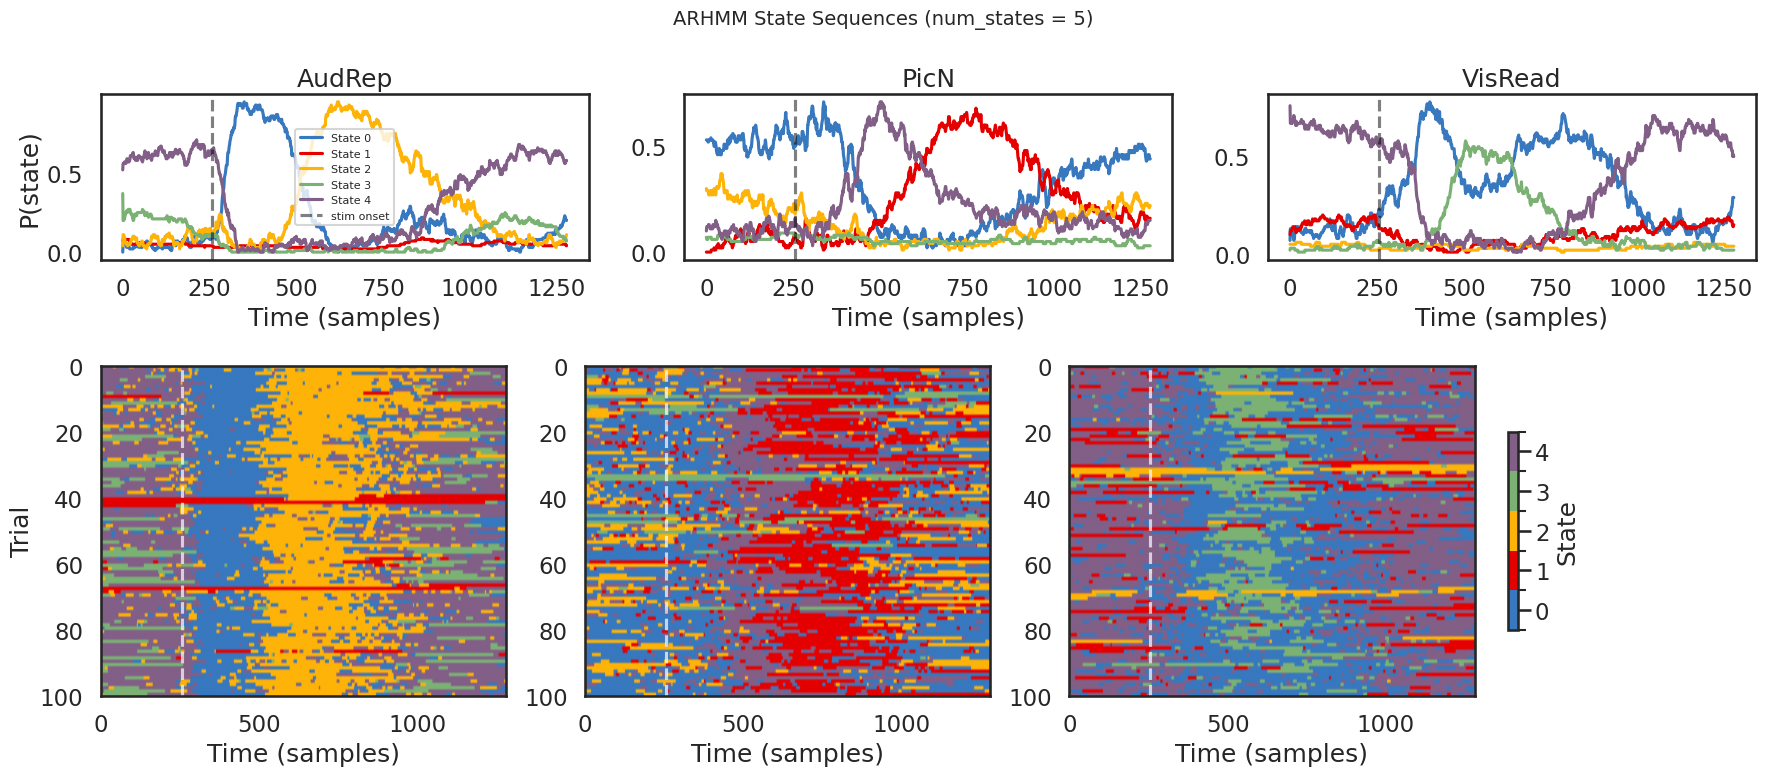

In [62]:
fig, axes = plt.subplots(2, 3, figsize = (18, 8), gridspec_kw = {'height_ratios': [1, 2]})

cmap5 = ListedColormap(colors[:num_states])
norm5 = BoundaryNorm(jnp.arange(num_states + 1) - 0.5, num_states)

for col, task in enumerate(tasks):
    
    # -- Top row: average occupancy --
    ax = axes[0, col]
    # One-hot encode states and average across trials
    occupancy = jnp.zeros((100, 1280, num_states))
    for k in range(num_states):
        occupancy = occupancy.at[:, :, k].set((state_seqs[task] == k).astype(float))
    avg_occupancy = occupancy.mean(axis = 0) # (1280, num_states)

    for k in range(num_states):
        ax.plot(avg_occupancy[:, k], label = f"State {k}", color = colors[k])
    ax.axvline(x = 256, color = 'k', linestyle = '--', alpha = 0.5, label = 'stim onset')
    ax.set_xlabel("Time (samples)")
    ax.set_title(task)
    if col == 0:
        ax.set_ylabel("P(state)")
        ax.legend(fontsize  = 8)

    # -- Bottom row: trial x time raster ---
    ax = axes[1, col]
    im = ax.imshow(state_seqs[task], aspect = "auto", cmap = cmap5, norm = norm5, extent = [0, 1280, 100, 0])
    ax.axvline(x = 256, color = 'w', linestyle = '--', alpha = 0.7)
    ax.set_xlabel("Time (samples)")
    if col == 0:
        ax.set_ylabel("Trial")
    

plt.suptitle("ARHMM State Sequences (num_states = 5)", fontsize = 14)
plt.tight_layout()
cbar = plt.colorbar(im, ax=axes[1, :], label="State", shrink=0.6, pad=0.02)
cbar.set_ticks(range(num_states))
plt.show()